In [ ]:
#%%
import math
import numpy as np

import inspect
import importlib

import scipy.interpolate
from scipy import stats
from scipy.stats import norm

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
from matplotlib import patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.lines as mlines
from matplotlib import colormaps

import seaborn as sns


plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

from fft_architecture_exploration                        import *

path_to_save_svg = "Saved_Data"


rng = np.random.default_rng(42)

In [ ]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [ ]:

import matplotlib.colors as mcolors

# Define base colors for each row
base_colors = {
    'red': '#f8333c',      # LightRed as base
    'blue': "#64ABD4",     # DeepBlue as base  
    'green': '#44af69',    # Green as base
    'orange': '#fcab10',   # Orange as base
    'purple': '#800080'    # Standard purple as base
}

# Create 10 nuances for each color by varying lightness
color_array = np.zeros((5, 10), dtype=object)

for i, (color_name, base_hex) in enumerate(base_colors.items()):
    base_rgb = mcolors.hex2color(base_hex)
    for j in range(10):
        # Create lighter/darker variations by scaling RGB values
        # Use a non-linear scaling for better visual distribution
        scale = 0.5 + 0.5 * (j / 9) ** 0.7  # 0.5 to 1.0 with curve
        if color_name == 'purple':
            # For purple, create a nice gradient from dark to light
            lightness = j / 9.0  # 0 to 1
            if j < 5:
                # Dark to medium purples
                r = 0.5 + 0.3 * (j / 4.0)
                b = 0.5 + 0.3 * (j / 4.0)
                g = 0.0 + 0.2 * (j / 4.0)
            else:
                # Medium to light purples
                r = 0.8 + 0.2 * ((j - 5) / 4.0)
                b = 0.8 + 0.2 * ((j - 5) / 4.0)
                g = 0.4 + 0.4 * ((j - 5) / 4.0)
            color_array[i, j] = mcolors.rgb2hex((r, g, b))
        else:
            # For other colors, scale from darker to lighter
            if j < 5:
                # Darker variations (scale down)
                scaled_rgb = tuple(max(0, min(1, c * (0.4 + 0.6 * (j / 4.0)))) for c in base_rgb)
            else:
                # Lighter variations (scale up)
                scaled_rgb = tuple(max(0, min(1, c * (1.0 + 0.6 * ((j - 5) / 4.0)))) for c in base_rgb)
            color_array[i, j] = mcolors.rgb2hex(scaled_rgb)

# Rename rows for clarity
color_names = ['red', 'blue', 'green', 'orange', 'purple']

In [ ]:



importlib.reload(sys.modules['fft_architecture_exploration'])
from fft_architecture_exploration import * 

In [ ]:
analysis_Mem_type  = np.array([1]) # 0: 1xSP SRAM,   1: 2xSP SRAM, 2: 2xHalf-size SP SRAM,  3: 1xDP SRAM
analysis_nMem_type = len(analysis_Mem_type)

baseline_area    = 10/((90/65)**2)
add_baseline_area = True

baseline_techNode= 65 #10
baseline_energy  = nFFT* 5.7e-9
baseline_latency = nFFT* 80
baseline_power   = baseline_energy / baseline_latency

area_overlap = 0#0.095

beta = 1

In [ ]:
# ----------------------------------------------------------------------
#           RATIO
# ----------------------------------------------------------------------


para_theor_Speedup        = baseline_latency        / para_theor_Latency                                
para_theor_Power          = para_theor_Energy       / para_theor_Latency
   
pipePara_theor_Speedup    = baseline_latency            / pipePara_theor_Latency                                
pipePara_theor_Power      = pipePara_theor_Energy       / pipePara_theor_Latency 

pipe_theor_Speedup        = baseline_latency        / pipe_theor_Latency                                
pipe_theor_Power          = pipe_theor_Energy       / pipe_theor_Latency

# ----------------------------------------------------------------------

theor_Area             = np.array([pipe_theor_Area         ,  para_theor_Area     ,  pipePara_theor_Area]) - area_overlap
theor_Latency          = np.array([pipe_theor_Latency      ,  para_theor_Latency  ,  pipePara_theor_Latency])
theor_Energy           = np.array([pipe_theor_Energy       ,  para_theor_Energy   ,  pipePara_theor_Energy])
theor_Speedup          = np.array([pipe_theor_Speedup      ,  para_theor_Speedup  ,  pipePara_theor_Speedup])                              
theor_Power            = np.array([pipe_theor_Power        ,  para_theor_Power    ,  pipePara_theor_Power]) 

# ----------------------------------------------------------------------

para_theor_area_ratio    = (para_theor_Area[:,:,np.newaxis]+baseline_area*add_baseline_area - area_overlap)    / baseline_area
para_theor_power_ratio   = para_theor_Power   / baseline_power
para_theor_energy_ratio  = para_theor_Energy  / baseline_energy
para_theor_latency_ratio = para_theor_Latency / baseline_latency
para_theor_speedup_ratio = 1/(para_theor_latency_ratio)


# ----------------------------------------------------------------------
pipe_theor_area_ratio    = (pipe_theor_Area[:,:,np.newaxis]+baseline_area*add_baseline_area - area_overlap)    / baseline_area
pipe_theor_power_ratio   = pipe_theor_Power   / baseline_power
pipe_theor_energy_ratio  = pipe_theor_Energy  / baseline_energy
pipe_theor_latency_ratio = pipe_theor_Latency / baseline_latency
pipe_theor_speedup_ratio = 1/(pipe_theor_latency_ratio)


# ----------------------------------------------------------------------
pipePara_theor_area_ratio    = (pipePara_theor_Area[:,:,np.newaxis]+baseline_area*add_baseline_area - area_overlap)    / baseline_area
pipePara_theor_power_ratio   = pipePara_theor_Power   / baseline_power
pipePara_theor_energy_ratio  = pipePara_theor_Energy  / baseline_energy
pipePara_theor_latency_ratio = pipePara_theor_Latency / baseline_latency
pipePara_theor_speedup_ratio = 1/(pipePara_theor_latency_ratio)

# ----------------------------------------------------------------------


theor_area_ratio        = np.array([pipe_theor_area_ratio       , para_theor_area_ratio    , pipePara_theor_area_ratio])  
theor_power_ratio       = np.array([pipe_theor_power_ratio      , para_theor_power_ratio   , pipePara_theor_power_ratio])
theor_energy_ratio      = np.array([pipe_theor_energy_ratio     , para_theor_energy_ratio  , pipePara_theor_energy_ratio])
theor_latency_ratio     = np.array([pipe_theor_latency_ratio    , para_theor_latency_ratio , pipePara_theor_latency_ratio])                              
theor_speedup_ratio     = np.array([pipe_theor_speedup_ratio    , para_theor_speedup_ratio , pipePara_theor_speedup_ratio]) 

# Monte Carlo from architecture exploration

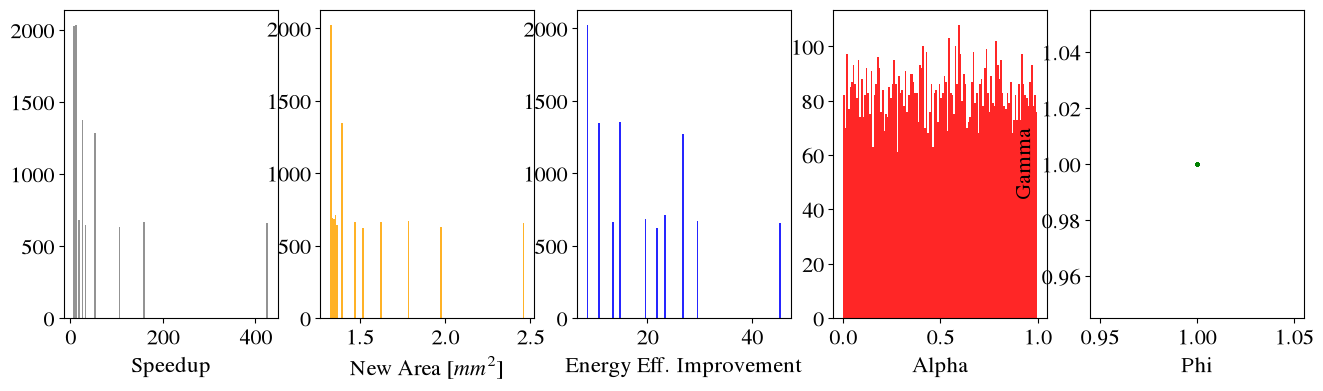

In [ ]:
N = 10000

mc_baseline_area = 0.6

mc_Mem_type  = np.array([1]) # 0: 1xSP SRAM,   1: 2xSP SRAM, 2: 2xHalf-size SP SRAM,  3: 1xDP SRAM
mc_nMem_type = len(mc_Mem_type)

# Random architecture selection
mc_mem  = rng.integers(low=0,high=mc_nMem_type, size= N)
mc_strat= rng.integers(low=0,high=3,            size= N)
mc_arch = rng.integers(low=0,high=arch_Dim,     size= N)

mc_mem_idx = mc_Mem_type[mc_mem]

mc_area_overhead     = theor_Area          [mc_strat,mc_arch,mc_mem_idx] 
mc_power_ratio       = theor_power_ratio   [mc_strat,mc_arch,mc_mem_idx] 
mc_energy_ratio      = theor_energy_ratio  [mc_strat,mc_arch,mc_mem_idx] 
mc_speedup_ratio     = theor_speedup_ratio [mc_strat,mc_arch,mc_mem_idx] 

# Impairment to speedup
mc_speedup_factor = rng.uniform(low=0.9, high=1, size=N) *0 +1
mc_speedup_ratio  = mc_speedup_ratio*mc_speedup_factor


# Impairment to energy
mc_energy_factor = rng.uniform(low=1, high=1.5, size=N) *0 +1
mc_energy_ratio  = mc_energy_ratio*mc_energy_factor


mc_power_ratio = (mc_energy_ratio) * mc_speedup_ratio

# Impairment to area
mc_area_factor = rng.uniform(low=1, high=1.5, size=N) *0 +1
mc_area_ratio  = ((mc_area_overhead*mc_area_factor)+mc_baseline_area)/mc_baseline_area


mc_alpha = (rng.uniform(low=0.001, high=0.999, size=N)) 


target_cor = 0.0
means = [0 ,0 ]
covariance_matrix = [
    [1, target_cor],
    [target_cor, 1]
]
# 2. Generate correlated multivariate normal variables
gaussian_samples = rng.multivariate_normal(means, covariance_matrix, size=N)
# 3. Transform the normal variables to uniform variables using the standard normal CDF
uniform_samples = norm.cdf(gaussian_samples)

mc_phiE   = uniform_samples[:,0] * 0+1
mc_phiA   = uniform_samples[:,1] * 0+1
# ----------------------------------------------------------------------
# 3. XASI METRIC
# ----------------------------------------------------------------------
#mc_asi_res     = asi_function(alpha=mc_alpha, area_ratio=mc_area_ratio, power_ratio=mc_power_ratio,print=False)
mc_asi_res     = (1- (mc_alpha * mc_area_ratio))/( (1 - mc_alpha) * mc_power_ratio)
#mc_asi_res     = (1- ((1-mc_phiA)*mc_alpha + (1-mc_phiE)*(1-mc_alpha) +(mc_phiA* mc_alpha * mc_area_ratio)  ) ) / ( (mc_phiE) * (1 - mc_alpha) * mc_power_ratio)
mc_ncf_fw_res  = (((1-mc_phiA) + mc_phiA*mc_area_ratio) * (mc_alpha)) +  (((1-mc_phiE) + mc_phiE*mc_energy_ratio )   * (1-mc_alpha))
mc_ncf_ft_res  = (((1-mc_phiA) + mc_phiA*mc_area_ratio) * (mc_alpha)) +  (((1-mc_phiE) + mc_phiE*mc_power_ratio  )   * (1-mc_alpha))



fig, ax = plt.subplots(1,5, figsize=(16,4))

ax[0].hist(mc_speedup_ratio, bins=120, color='Gray', alpha=0.85, edgecolor='none')
ax[0].set_xlabel('Speedup')
ax[1].hist(mc_area_ratio, bins=120, color='Orange', alpha=0.85, edgecolor='none')
ax[1].set_xlabel('New Area [$mm^2$]')
ax[2].hist(1/mc_energy_ratio, bins=120, color='Blue', alpha=0.85, edgecolor='none')
ax[2].set_xlabel('Energy Eff. Improvement')
ax[3].hist(mc_alpha, bins=120, color='Red', alpha=0.85, edgecolor='none')
ax[3].set_xlabel('Alpha')
ax[4].scatter(mc_phiE, mc_phiA, color='Green',s=2)
ax[4].set_xlabel('Phi')
ax[4].set_ylabel('Gamma')

plt.show()

C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_22640\2430949947.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2,0].legend()
C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_22640\2430949947.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2,1].legend()


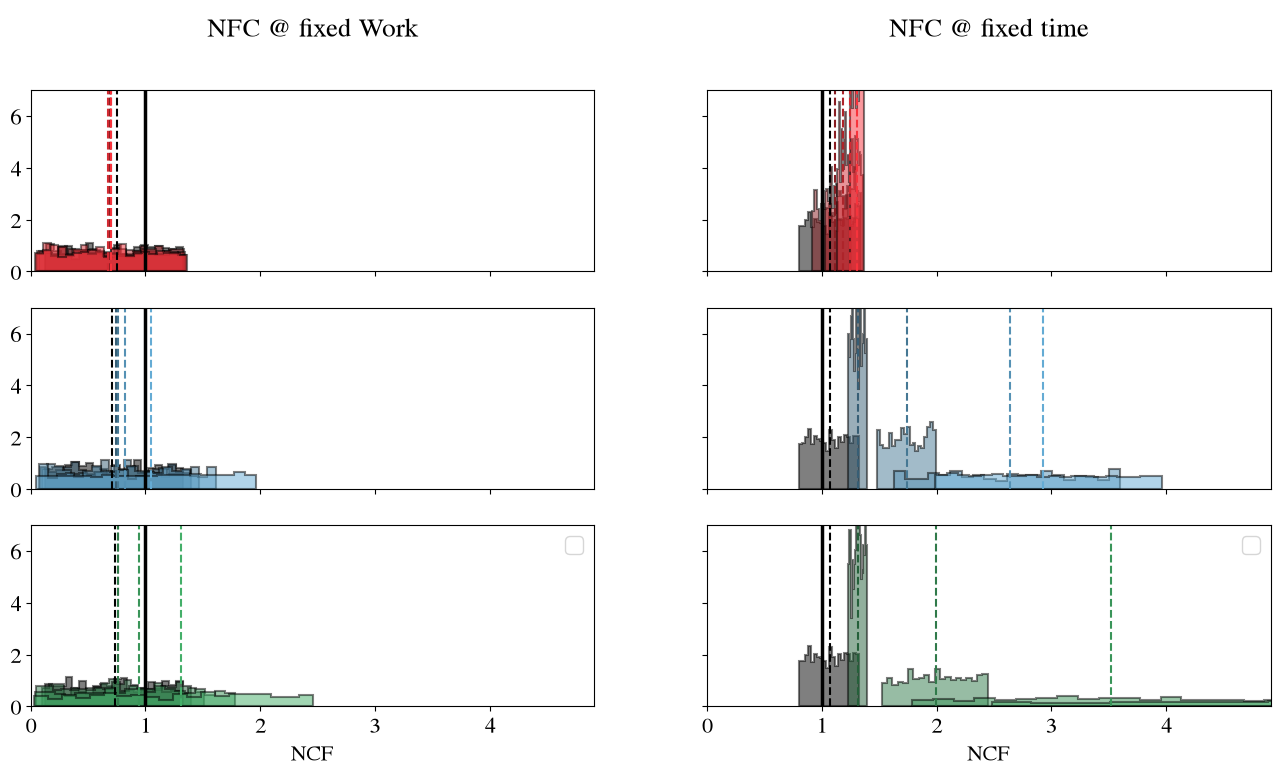

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 8),  sharey=True,  sharex=True)

nbins_fw = 20
nbins_ft = 20
# (a) NCF ratio distribution
ax = axes

fillHist=True
lwHist = 1.5
alphaHist = 0.5

for i in range(3):
    idx = np.where((mc_strat==i) & (mc_arch==0)) 
    distr = mc_ncf_fw_res[idx]
    ax[i,0].hist(distr, bins=nbins_fw,color = "black",  alpha=alphaHist,histtype='stepfilled',  fill=fillHist,linewidth = lwHist,density=True, ec='black')#'black')
    ax[i,0].axvline(np.median(distr), color='black', linestyle='--', linewidth=1.5)

    distr = mc_ncf_ft_res[np.where((mc_arch==0)) ]
    ax[i,1].hist(mc_ncf_ft_res[np.where((mc_arch==0)) ], bins=nbins_ft,color = "black", alpha=alphaHist,histtype='stepfilled',  fill=fillHist,linewidth = lwHist,density=True, ec='black')#'black')
    ax[i,1].axvline(np.median(distr), color='black', linestyle='--', linewidth=1.5)
    for j in range(1,arch_Dim):
        idx = np.where((mc_strat==i) & (mc_arch==j)) 

        distr = mc_ncf_fw_res[idx]
        ax[i,0].hist(distr, bins=nbins_fw,color = color_array[i,j],  alpha=alphaHist,histtype='stepfilled',  fill=fillHist,linewidth = lwHist, density=True, ec= 'black' if fillHist else color_array[i,j]) 
        ax[i,0].axvline(np.median(distr), color = color_array[i,j], linestyle='--', linewidth=1.5)

        distr = mc_ncf_ft_res[idx]
        ax[i,1].hist(distr, bins=nbins_ft,color = color_array[i,j],  alpha=alphaHist,histtype='stepfilled',  fill=fillHist,linewidth = lwHist, density=True, ec= 'black' if fillHist else color_array[i,j])
        ax[i,1].axvline(np.median(distr), color = color_array[i,j], linestyle='--', linewidth=1.5)

ax[0,0].set_title(f'NFC @ fixed Work\n')
ax[0,1].set_title(f'NFC @ fixed time\n')

ax[2,0].set_xlabel('NCF')
ax[2,0].legend()

ax[2,1].set_xlabel('NCF')
ax[2,1].legend()

#ax[0,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))
#ax[1,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))
#ax[2,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))

ax[0,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))
ax[1,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))
ax[2,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))


ax[0,0].set_ylim(0, 3)
ax[0,1].set_ylim(0, 7)


ax[0,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[1,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[2,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[0,1].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[1,1].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[2,1].axvline(1, color='black', linestyle='-', linewidth=2.5)

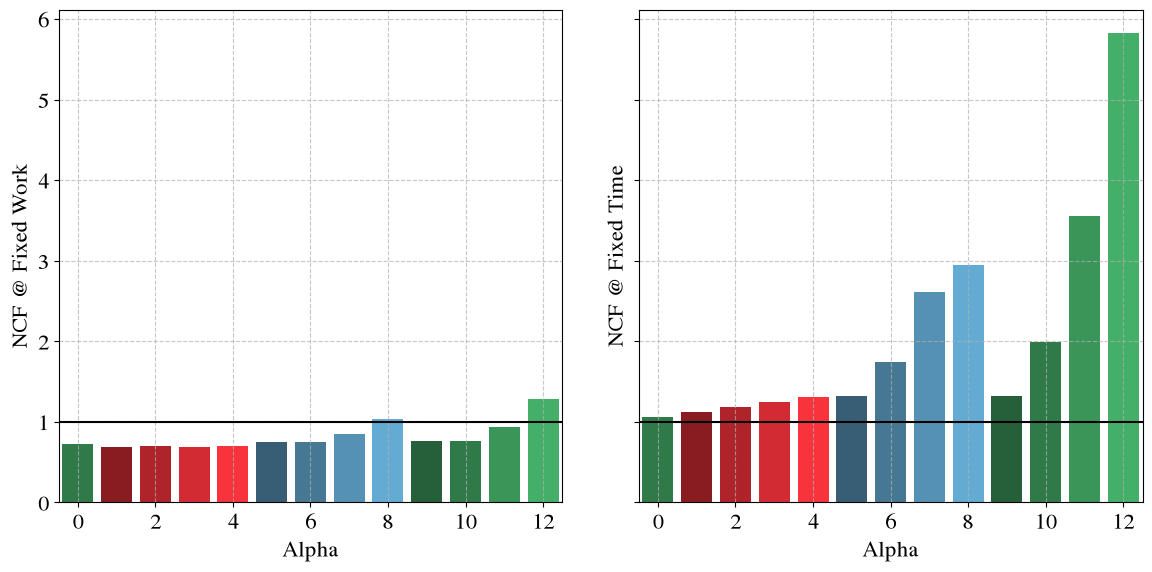

In [ ]:
# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(len(baseline_area),2,figsize=(12, 6*len(baseline_area)), sharey='row', squeeze=False)


for a in range(len(baseline_area)):
    ax[a,0].set_xlabel('ALpha')
    ax[a,1].set_xlabel('ALpha')
    ax[a,0].grid(True, which='both', linestyle='--', alpha=0.7)
    ax[a,1].grid(True, which='both', linestyle='--', alpha=0.7)

    # Add our accelerator
    count = 0
    idx = np.where((mc_strat==i) & (mc_arch==0)) 
    distr = mc_ncf_fw_res[idx]
    p = ax[a,0].bar(count,   np.sum(distr)/len(distr),   color = color_array[k,i])
    
    distr = mc_ncf_ft_res[idx]
    p = ax[a,1].bar(count,   np.sum(distr)/len(distr),   color = color_array[k,i])
    count+=1
    for i in range(3):
        
        for j in range(1,arch_Dim):

            idx = np.where((mc_strat==i) & (mc_arch==j)) 
            distr = mc_ncf_fw_res[idx]
            p = ax[a,0].bar(count,   np.sum(distr)/len(distr),   color = color_array[i,j])
            
            distr = mc_ncf_ft_res[idx]
            p = ax[a,1].bar(count,   np.sum(distr)/len(distr),   color = color_array[i,j])
            count+=1

    ax[a,0].hlines(y=1,xmin = -2,xmax= count+2, color= "black")
    ax[a,1].hlines(y=1,xmin = -2,xmax= count+2, color= "black")
    ax[a,0].set_xlim([0-0.5,count-0.5])
    ax[a,1].set_xlim([0-0.5,count-0.5])
    ax[a,0].set_ylim([0,None])
    ax[a,1].set_ylim([0,None])
    ax[a,0].set_xlabel("Alpha")
    ax[a,1].set_xlabel("Alpha")
    ax[a,0].set_ylabel("NCF @ Fixed Work")
    ax[a,1].set_ylabel("NCF @ Fixed Time")


# Add legend
fig.tight_layout()
plt.show()



C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_22640\2054861042.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  this_ax.set_xlim([0,1.05*np.max(mc_speedup_ratio)])


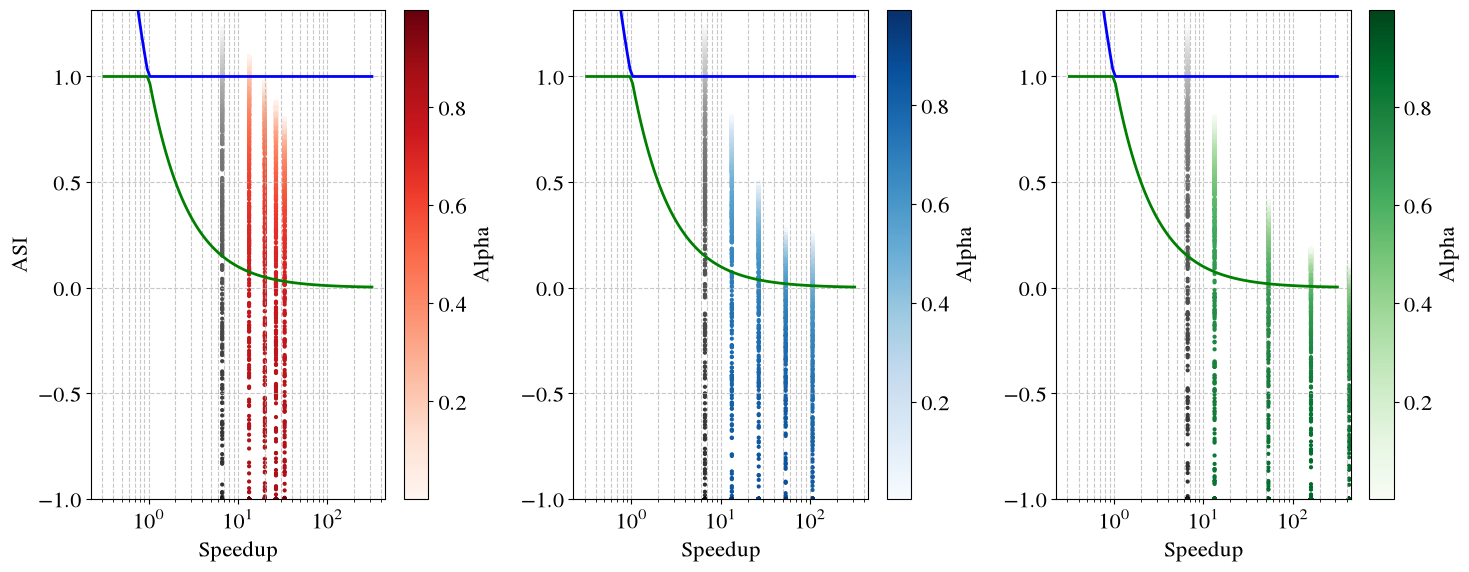

In [73]:
# ASI Framework separations
speedup_space = np.logspace(-0.5, 2.5, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')

for this_ax in ax:
    this_ax.plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xscale('log')
    this_ax.set_xlabel('Speedup')
    this_ax.set_ylim([-1,1.05*np.max(mc_asi_res)])
    this_ax.set_xlim([0,1.05*np.max(mc_speedup_ratio)])
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)


arch_color_map = ['Reds', 'Blues', 'Greens']
for i in range(3):
    idx = np.where((mc_strat==i) & (mc_arch==0)) 
    distr = mc_asi_res[idx]
    speedu_distr = mc_speedup_ratio[idx]
    aplha_dist = mc_alpha[idx]
    p = ax[i].scatter(speedu_distr,   np.maximum(distr,-1),   c=aplha_dist,cmap='Greys',  s=4, label='Our Accelerator')
    for j in range(1,arch_Dim):
        idx = np.where((mc_strat==i) & (mc_arch==j)) 
        distr = mc_asi_res[idx]
        speedu_distr = mc_speedup_ratio[idx]
        aplha_dist = mc_alpha[idx]
        p = ax[i].scatter(speedu_distr,   np.maximum(distr,-1),   c=aplha_dist,cmap=arch_color_map[i],  s=4, label='Our Accelerator')
    fig.colorbar(p,ax=ax[i],orientation='vertical',label='Alpha')

# Add legend
fig.tight_layout()
plt.show()


C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_22640\682479300.py:19: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0,1.05*np.max(mc_speedup_ratio)])


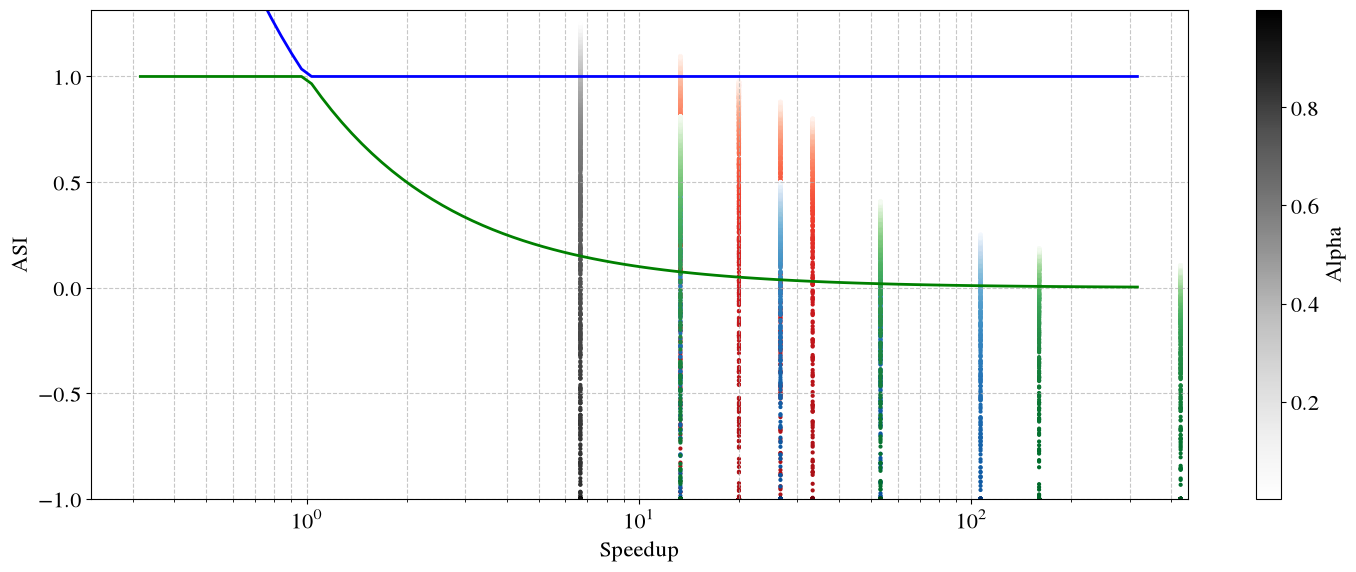

In [74]:
# ASI Framework separations
speedup_space = np.logspace(-0.5, 2.5, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,1,figsize=(15, 6))
ax.set_ylabel('ASI')

ax.plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
ax.plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')
ax.set_xscale('log')
ax.set_xlabel('Speedup')
ax.set_ylim([-1,1.05*np.max(mc_asi_res)])
ax.set_xlim([0,1.05*np.max(mc_speedup_ratio)])
ax.grid(True, which='both', linestyle='--', alpha=0.7)
#this_ax.set_xlim(10, 1e7)


arch_color_map = ['Reds', 'Blues', 'Greens']
for i in range(3):
    for j in range(1,arch_Dim):
        idx = np.where((mc_strat==i) & (mc_arch==j)) 
        distr = mc_asi_res[idx]
        speedu_distr = mc_speedup_ratio[idx]
        aplha_dist = mc_alpha[idx]
        p = ax.scatter(speedu_distr,   np.maximum(distr,-1),   c=aplha_dist,cmap=arch_color_map[i],  s=4)

idx = np.where(mc_arch==0) 
distr = mc_asi_res[idx]
speedu_distr = mc_speedup_ratio[idx]
aplha_dist = mc_alpha[idx]
p = ax.scatter(speedu_distr,   np.maximum(distr,-1),   c=aplha_dist,cmap="Greys",  s=4)

fig.colorbar(p,ax=ax,orientation='vertical',label='Alpha')

# Add legend
fig.tight_layout()
plt.show()


ValueError: x and y must be the same size

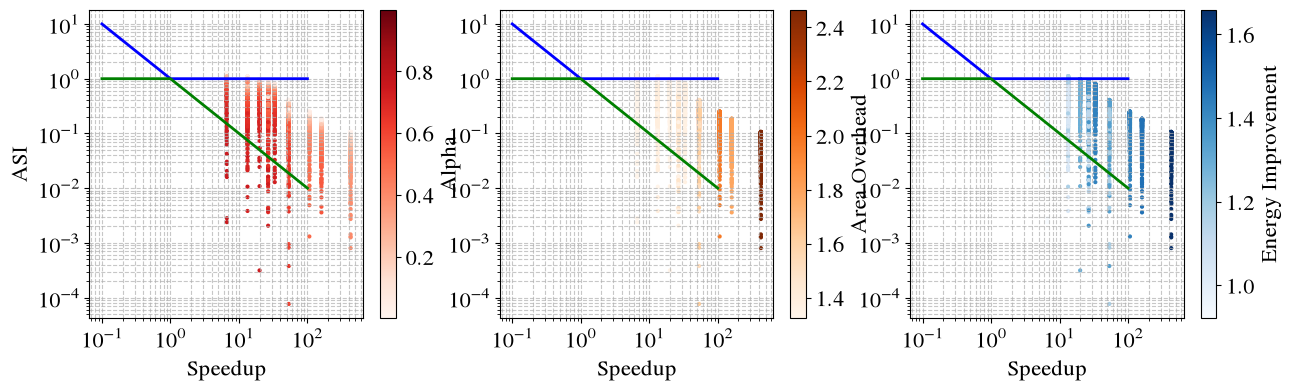

In [75]:
# ASI Framework separations
speedup_space = np.logspace(-1, 2, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 4))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.loglog(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.loglog(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xlabel('Speedup')
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(mc_speedup_ratio,   mc_asi_res,   c=mc_alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

p = ax[1].scatter(mc_speedup_ratio,   mc_asi_res,   c=mc_area_ratio,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')

p = ax[2].scatter(mc_speedup_ratio,   mc_asi_res,   c=np.log10(1/mc_energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')


# Add our accelerator
for i in range(our_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[1].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[2].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')

p = ax[0].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[1].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[2].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
# Add legend
fig.tight_layout()
plt.show()


C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_36292\2932278765.py:19: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  this_ax.set_xlim([0,1.1*np.max(mc_speedup_ratio)])


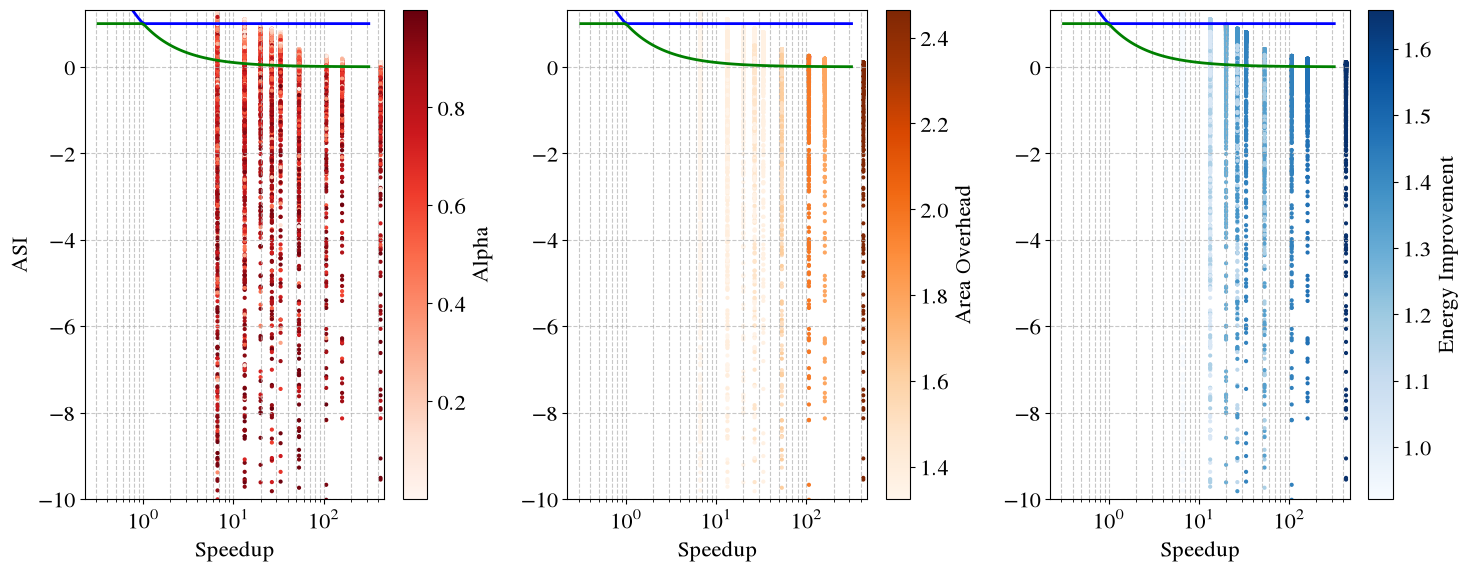

In [ ]:
# ASI Framework separations
speedup_space = np.logspace(-0.5, 2.5, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xscale('log')
    this_ax.set_xlabel('Speedup')
    this_ax.set_xlim([0,1.1*np.max(mc_speedup_ratio)])
    this_ax.set_ylim([-10,1.05*np.max(mc_asi_res)])
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(mc_speedup_ratio,   mc_asi_res,   c=mc_alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')
p = ax[1].scatter(mc_speedup_ratio,   mc_asi_res,   c=mc_area_ratio,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')
p = ax[2].scatter(mc_speedup_ratio,   mc_asi_res,   c=np.log10(1/mc_energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')

# Add legend
fig.tight_layout()
plt.show()


In [ ]:
N = 10000

mc_baseline_area = 0.6

mc_Mem_type  = np.array([1]) # 0: 1xSP SRAM,   1: 2xSP SRAM, 2: 2xHalf-size SP SRAM,  3: 1xDP SRAM
mc_nMem_type = len(mc_Mem_type)

# Random architecture selection
mc_mem  = rng.integers(low=0,high=mc_nMem_type, size= N)
mc_strat= rng.integers(low=0,high=3,            size= N)
mc_arch = rng.integers(low=0,high=arch_Dim,     size= N)

mc_mem_idx = mc_Mem_type[mc_mem]

mc_area_overhead     = theor_Area          [mc_strat,mc_arch,mc_mem_idx] 
mc_power             = theor_Power   [mc_strat,mc_arch,mc_mem_idx] 
mc_energy            = theor_Energy  [mc_strat,mc_arch,mc_mem_idx] 
mc_speedup           = theor_Speedup [mc_strat,mc_arch,mc_mem_idx] 

mc_power = (mc_energy_ratio) * mc_speedup_ratio

# -------------Carbon intensity
# Operational

F_p_J_grid = 1.27e-07 #kgCO2/J
F_p_J_batt = 1.16e-05 #kgCO2/J
F_p_pt = np.array([F_p_J_grid,F_p_J_batt])

mc_F_p_J = F_p_pt[rng.integers(low=0,high=1+1,     size= N)]

fs_log_min = 0
fs_log_max = 4

mc_fs = 10**rng.uniform(low=fs_log_min, high=fs_log_max+1, size=N) 

mc_lifetime = rng.uniform(low=9, high=10+1, size=N) 

# Embodied
F_p_mm2 = 0.97/100

# ----------------------------------------------------------------------
# 3. XASI METRIC
# ----------------------------------------------------------------------

mc_cf = (mc_area_overhead * F_p_mm2)  - (mc_fs*mc_F_p_J*(365*24*60*60*mc_lifetime))*((baseline_energy-mc_energy) /nFFT)

#mc_cf = (mc_area_overhead * F_p_mm2)  + (mc_fs*mc_F_p_J*(365*24*60*60*mc_lifetime))*((mc_energy) /nFFT)


0 arch : Mean -0.08 	 Median 0.00
0 arch : Mean -8.06e-02 	 Median 1.57e-03
0 arch : Mean -8.12e-02 	 Median 1.36e-03
0 arch : Mean -8.28e-02 	 Median 1.38e-03
0 arch : Mean -9.20e-02 	 Median 1.23e-03
1 arch : Mean -0.09 	 Median 0.00
1 arch : Mean -6.66e-02 	 Median 1.75e-03
1 arch : Mean -7.18e-02 	 Median 2.09e-03
1 arch : Mean -7.27e-02 	 Median 2.91e-03
1 arch : Mean -7.95e-02 	 Median 4.97e-03
2 arch : Mean -0.06 	 Median 0.00
2 arch : Mean -7.96e-02 	 Median 1.52e-03
2 arch : Mean -8.22e-02 	 Median 2.14e-03
2 arch : Mean -8.70e-02 	 Median 4.16e-03
2 arch : Mean -7.50e-02 	 Median 7.65e-03


C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_39324\1672317989.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend()


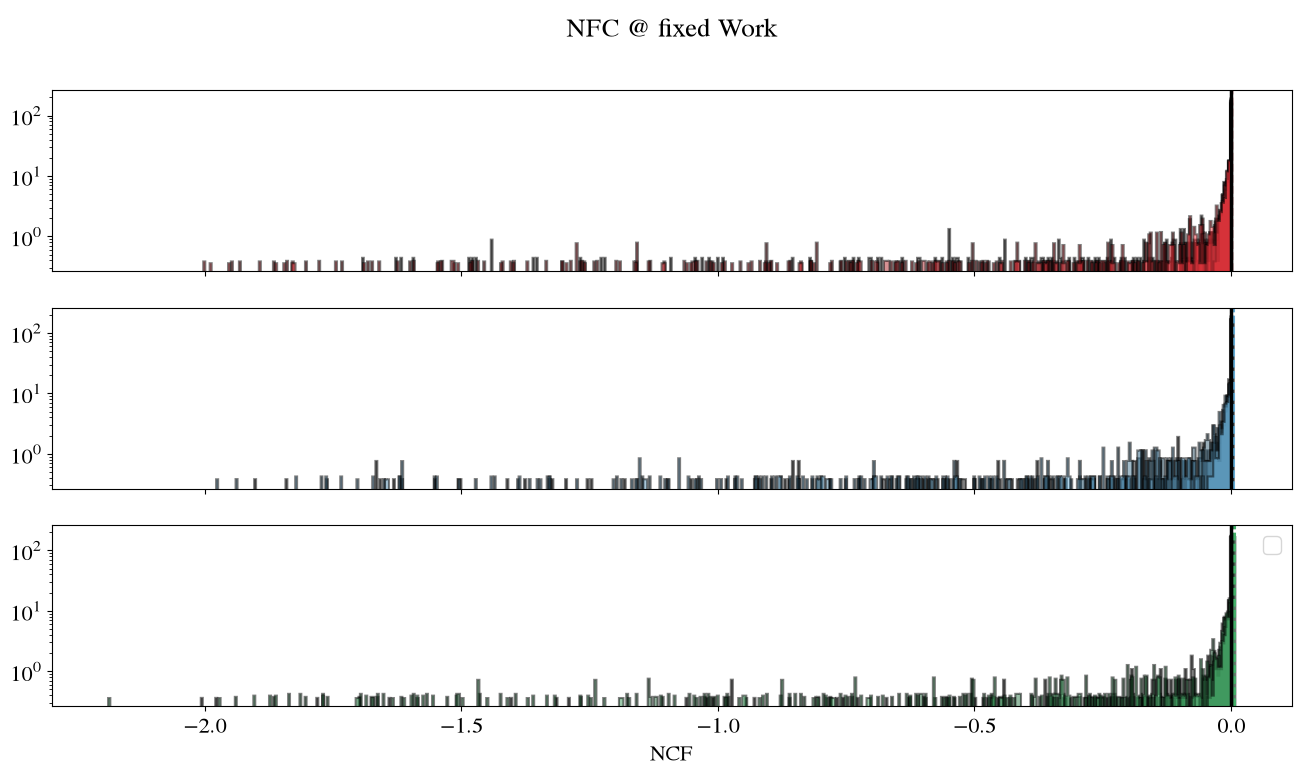

In [40]:

fig, axes = plt.subplots(3, 1, figsize=(16, 8),  sharey=True,  sharex=True)

nbins_fw = 500
nbins_ft = 500
# (a) NCF ratio distribution
ax = axes

fillHist=True
lwHist = 1.5
alphaHist = 0.5

for i in range(3):
    idx = np.where((mc_strat==i) & (mc_arch==0)) 
    distr = mc_cf[idx]
    ax[i].hist((distr), bins=nbins_fw,color = "black",  alpha=alphaHist,histtype='stepfilled',  fill=fillHist,linewidth = lwHist,density=True, ec='black')#'black')
    ax[i].axvline((np.median(distr)), color='black', linestyle='--', linewidth=1.5)
    print("%i arch : Mean %.2f \t Median %.2f"%(i,np.mean(distr), np.median(distr)))
    for j in range(1,arch_Dim):
        idx = np.where((mc_strat==i) & (mc_arch==j)) 

        distr = mc_cf[idx]
        ax[i].hist((distr), bins=nbins_fw,color = color_array[i,j],  alpha=alphaHist,histtype='stepfilled',  fill=fillHist,linewidth = lwHist, density=True, ec= 'black' if fillHist else color_array[i,j]) 
        ax[i].axvline((np.median(distr)), color = color_array[i,j], linestyle='--', linewidth=1.5)
        print("%i arch : Mean %.2e \t Median %.2e"%(i,np.mean(distr), np.median(distr)))
   
ax[0].set_title(f'NFC @ fixed Work\n')

ax[2].set_xlabel('NCF')
ax[2].legend()


#ax[0,0].set_xlim(0, np.percentile(mc_cf,99))# 1.05*np.percentile(mc_ncf_fw_res, 99.9))
#ax[1,0].set_xlim(0, np.percentile(mc_cf,99))# 1.05*np.percentile(mc_ncf_fw_res, 99.9))
#ax[2,0].set_xlim(0, np.percentile(mc_cf,99))# 1.05*np.percentile(mc_ncf_fw_res, 99.9))
#ax[0,1].set_xlim(0, np.percentile(mc_cf,99))# np.percentile(mc_ncf_ft_res, 95))
#ax[1,1].set_xlim(0, np.percentile(mc_cf,99))# np.percentile(mc_ncf_ft_res, 95))
#ax[2,1].set_xlim(0, np.percentile(mc_cf,99))# np.percentile(mc_ncf_ft_res, 95))
#
#
#ax[0,0].set_ylim(0, 3)
#ax[0,1].set_ylim(0, 7)


ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[2].set_yscale('log')

#ax[0].set_xscale('log')
#ax[1].set_xscale('log')
#ax[2].set_xscale('log')

ax[0].axvline(0, color='black', linestyle='-', linewidth=2.5)
ax[1].axvline(0, color='black', linestyle='-', linewidth=2.5)
ax[2].axvline(0, color='black', linestyle='-', linewidth=2.5)

In [ ]:

fig, axes = plt.subplots(3, 1, figsize=(16, 8),  sharey=True,  sharex=True)

nbins_fw = 20
nbins_ft = 20
# (a) NCF ratio distribution
ax = axes

fillHist=True
lwHist = 1.5
alphaHist = 0.5

for i in range(3):
    idx = np.where((mc_strat==i) & (mc_arch==0)) 
    distr = mc_cf[idx]
    ax[i,0].hist(distr, bins=nbins_fw,color = "black",  alpha=alphaHist,histtype='stepfilled',  fill=fillHist,linewidth = lwHist,density=True, ec='black')#'black')
    ax[i,0].axvline(np.median(distr), color='black', linestyle='--', linewidth=1.5)

    for j in range(1,arch_Dim):
        idx = np.where((mc_strat==i) & (mc_arch==j)) 

        distr = mc_cf[idx]
        ax[i,0].hist(distr, bins=nbins_fw,color = color_array[i,j],  alpha=alphaHist,histtype='stepfilled',  fill=fillHist,linewidth = lwHist, density=True, ec= 'black' if fillHist else color_array[i,j]) 
        ax[i,0].axvline(np.median(distr), color = color_array[i,j], linestyle='--', linewidth=1.5)

 
ax[0,0].set_title(f'NFC @ fixed Work\n')
ax[0,1].set_title(f'NFC @ fixed time\n')

ax[2,0].set_xlabel('NCF')
ax[2,0].legend()

ax[2,1].set_xlabel('NCF')
ax[2,1].legend()

#ax[0,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))
#ax[1,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))
#ax[2,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))

#ax[0,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))
#ax[1,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))
#ax[2,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))
#
#
#ax[0,0].set_ylim(0, 3)
#ax[0,1].set_ylim(0, 7)


ax[0,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[1,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[2,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[0,1].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[1,1].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[2,1].axvline(1, color='black', linestyle='-', linewidth=2.5)